# Cascade R-CNN HRNet AGAR tuning and evaluation notebook

This notebook is made for testing **Cascade R-CNN with HRNet-W18 + HRFPN** on the AGAR tiled dataset.

It is safe by default. Expensive or destructive steps only run when their switch is set to `True`.

Main goals:

- Create 512 × 512 tiled datasets with overlap and padding
- Write an HRNet Cascade R-CNN config
- Write short hyperparameter tuning configs
- Run optional tuning experiments
- Collect validation metrics from MMDetection logs
- Run final evaluation and confusion matrix commands

## Safety switches

Keep these switches on `False` first. Turn on one section at a time.

In [ ]:
import seaborn as sns

# =========================
# SAFETY SWITCHES
# =========================

# Keep dataset-writing and training steps off when you only want to evaluate
# the existing 3-epoch HRNet checkpoint.
RUN_TILING_512 = False           # Creates/overwrites agar/tiles_512 files
RUN_CLEANING_512 = False         # Creates/overwrites cleaned 512 COCO JSON files
RUN_COUNTABLE_FILTER_512 = False # Creates/overwrites countable 512 COCO JSON files
RUN_WRITE_HRNET_BASE_CONFIG = False
RUN_WRITE_TUNING_CONFIGS = False
RUN_TUNING = False               # Trains multiple HRNet tuning runs
RUN_COLLECT_TUNING_RESULTS = False

# Turn this on to evaluate the existing 3-epoch HRNet checkpoint.
RUN_EVALUATE_PARTIAL_HRNET = True

# Recommended evaluation run:
# 1. Run imports and project paths.
# 2. Skip tiling/training cells.
# 3. Run the section: Evaluation of partially trained HRNet model.


## Imports and environment check

In [ ]:
import os
import re
import json
import shutil
import subprocess
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import cv2
    print("cv2 imported")
except Exception as e:
    print("cv2 import failed:", e)

try:
    import torch
    print("PyTorch version:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU name:", torch.cuda.get_device_name(0))
except Exception as e:
    print("PyTorch check failed:", e)

# TensorFlow is not needed for MMDetection.
print("This notebook uses PyTorch/MMDetection, not TensorFlow.")

## Project paths

The notebook expects to run from inside `~/mmdetection` or with the same folder available.

In [ ]:
PROJECT_ROOT = Path("/home/jaden/mmdetection")
CONFIG_DIR = PROJECT_ROOT / "configs" / "agar"
WORK_DIR = PROJECT_ROOT / "work_dirs"

SOURCE_DATA_ROOT = PROJECT_ROOT / "agar" / "agar_dataset_coco"
TILES_512_ROOT = PROJECT_ROOT / "agar" / "tiles_512"

R50_BASE_CONFIG = CONFIG_DIR / "cascade_rcnn_r50_fpn_agar_tiles.py"
HRNET_BASE_CONFIG = CONFIG_DIR / "cascade_rcnn_hrnet_w18_hrfpn_agar_tiles_512.py"
HYPERPARAM_CONFIG_DIR = CONFIG_DIR / "hparam_tuning_hrnet"
HYPERPARAM_CONFIG_DIR.mkdir(parents=True, exist_ok=True)

paths_to_check = {
    "PROJECT_ROOT": PROJECT_ROOT,
    "CONFIG_DIR": CONFIG_DIR,
    "R50_BASE_CONFIG": R50_BASE_CONFIG,
    "SOURCE_DATA_ROOT": SOURCE_DATA_ROOT,
    "TILES_512_ROOT": TILES_512_ROOT,
}

for name, path in paths_to_check.items():
    print(f"{name}: {path} | exists={path.exists()}")

## Optional 512 × 512 tiling with overlap and padding

This follows the patch logic from the paper: patches are 512 × 512 pixels, with overlap during sliding-window extraction. Padding is used at image edges so colonies near borders are not dropped.

Only tiles containing annotations are kept for training and validation.

In [ ]:
TILE_SIZE = 512
OVERLAP = 0.10
STRIDE = int(TILE_SIZE * (1 - OVERLAP))

print("Tile size:", TILE_SIZE)
print("Overlap:", OVERLAP)
print("Stride:", STRIDE)


def pad_tile(tile, tile_size=512):
    h, w = tile.shape[:2]
    if h == tile_size and w == tile_size:
        return tile
    padded = np.zeros((tile_size, tile_size, tile.shape[2]), dtype=tile.dtype)
    padded[:h, :w] = tile
    return padded


def tile_image_with_padding(img, anns, original_file_name, image_id_start, ann_id_start, out_img_dir):
    """Split one image into padded 512 tiles and keep only tiles containing annotations."""
    h, w = img.shape[:2]
    images = []
    annotations = []

    img_id = image_id_start
    ann_id = ann_id_start

    x_starts = list(range(0, max(w - TILE_SIZE + 1, 1), STRIDE))
    y_starts = list(range(0, max(h - TILE_SIZE + 1, 1), STRIDE))

    if not x_starts or x_starts[-1] != max(w - TILE_SIZE, 0):
        x_starts.append(max(w - TILE_SIZE, 0))
    if not y_starts or y_starts[-1] != max(h - TILE_SIZE, 0):
        y_starts.append(max(h - TILE_SIZE, 0))

    for y in y_starts:
        for x in x_starts:
            x_end = min(x + TILE_SIZE, w)
            y_end = min(y + TILE_SIZE, h)

            tile = img[y:y_end, x:x_end]
            tile = pad_tile(tile, TILE_SIZE)

            tile_annotations = []

            for ann in anns:
                bx, by, bw, bh = ann["bbox"]

                # Skip boxes with no overlap.
                if bx + bw <= x or by + bh <= y or bx >= x_end or by >= y_end:
                    continue

                new_x = max(bx - x, 0)
                new_y = max(by - y, 0)
                new_w = min(bx + bw, x_end) - max(bx, x)
                new_h = min(by + bh, y_end) - max(by, y)

                if new_w <= 1 or new_h <= 1:
                    continue

                tile_annotations.append({
                    "id": ann_id,
                    "image_id": img_id,
                    "category_id": ann["category_id"],
                    "bbox": [float(new_x), float(new_y), float(new_w), float(new_h)],
                    "area": float(new_w * new_h),
                    "iscrowd": ann.get("iscrowd", 0),
                })
                ann_id += 1

            if len(tile_annotations) == 0:
                continue

            stem = Path(original_file_name).stem
            file_name = f"{stem}_x{x}_y{y}.jpg"
            cv2.imwrite(str(Path(out_img_dir) / file_name), tile)

            images.append({
                "id": img_id,
                "file_name": file_name,
                "height": TILE_SIZE,
                "width": TILE_SIZE,
            })

            annotations.extend(tile_annotations)
            img_id += 1

    return images, annotations, img_id, ann_id


def process_coco_512(input_json, img_dir, out_json, out_img_dir):
    """Tile a COCO dataset split and save the new COCO annotation file."""
    out_img_dir = Path(out_img_dir)
    out_img_dir.mkdir(parents=True, exist_ok=True)
    Path(out_json).parent.mkdir(parents=True, exist_ok=True)

    with open(input_json, "r") as f:
        coco = json.load(f)

    annotations_by_image = {}
    for ann in coco["annotations"]:
        annotations_by_image.setdefault(ann["image_id"], []).append(ann)

    all_images = []
    all_annotations = []

    img_id = 1
    ann_id = 1

    for img_info in coco["images"]:
        img_path = Path(img_dir) / img_info["file_name"]
        img = cv2.imread(str(img_path))

        if img is None:
            print(f"Skipping unreadable image: {img_path}")
            continue

        anns = annotations_by_image.get(img_info["id"], [])

        imgs, anns_out, img_id, ann_id = tile_image_with_padding(
            img=img,
            anns=anns,
            original_file_name=img_info["file_name"],
            image_id_start=img_id,
            ann_id_start=ann_id,
            out_img_dir=out_img_dir,
        )

        all_images.extend(imgs)
        all_annotations.extend(anns_out)

    out = {
        "images": all_images,
        "annotations": all_annotations,
        "categories": coco["categories"],
    }

    with open(out_json, "w") as f:
        json.dump(out, f)

    print(f"Saved tiled annotations: {out_json}")
    print(f"Saved tiled images to: {out_img_dir}")
    print(f"Images: {len(all_images)}")
    print(f"Annotations: {len(all_annotations)}")

### Run 512 tiling

This writes to `agar/tiles_512`, not to your old `agar/tiles` folder.

In [5]:
if RUN_TILING_512:
    for split in ["train", "val"]:
        process_coco_512(
            input_json=SOURCE_DATA_ROOT / split / "annotations" / f"instances_{split}.json",
            img_dir=SOURCE_DATA_ROOT / split / "images",
            out_json=TILES_512_ROOT / f"instances_{split}.json",
            out_img_dir=TILES_512_ROOT / split / "images",
        )
else:
    print("Skipping 512 tiling because RUN_TILING_512 = False")

Saved tiled annotations: /home/jaden/mmdetection/agar/tiles_512/instances_train.json
Saved tiled images to: /home/jaden/mmdetection/agar/tiles_512/train/images
Images: 189589
Annotations: 554346
Saved tiled annotations: /home/jaden/mmdetection/agar/tiles_512/instances_val.json
Saved tiled images to: /home/jaden/mmdetection/agar/tiles_512/val/images
Images: 24125
Annotations: 68201


## Annotation cleaning for 512 tiles

In [ ]:
MIN_BOX_SIZE = 3

SETS_512 = {
    "train": {
        "json_in": TILES_512_ROOT / "instances_train.json",
        "json_out": TILES_512_ROOT / "instances_train_clean.json",
        "img_dir": TILES_512_ROOT / "train" / "images",
    },
    "val": {
        "json_in": TILES_512_ROOT / "instances_val.json",
        "json_out": TILES_512_ROOT / "instances_val_clean.json",
        "img_dir": TILES_512_ROOT / "val" / "images",
    },
}


def clean_coco_annotations(json_path, out_path, img_dir):
    with open(json_path, "r") as f:
        coco = json.load(f)

    images = coco["images"]
    annotations = coco["annotations"]
    images_by_id = {img["id"]: img for img in images}

    valid_annotations = []
    removed_no_bbox = 0
    removed_bad_bbox = 0
    removed_tiny_bbox = 0
    removed_missing_image = 0

    for ann in annotations:
        bbox = ann.get("bbox")

        if bbox is None:
            removed_no_bbox += 1
            continue
        if len(bbox) != 4:
            removed_bad_bbox += 1
            continue

        x, y, w, h = bbox
        if w <= 0 or h <= 0:
            removed_bad_bbox += 1
            continue
        if w < MIN_BOX_SIZE or h < MIN_BOX_SIZE:
            removed_tiny_bbox += 1
            continue
        if ann["image_id"] not in images_by_id:
            removed_missing_image += 1
            continue

        valid_annotations.append(ann)

    valid_image_ids = {ann["image_id"] for ann in valid_annotations}

    valid_images = []
    removed_empty_after_cleaning = 0
    removed_unreadable = 0
    removed_missing_file = 0

    for img in images:
        if img["id"] not in valid_image_ids:
            removed_empty_after_cleaning += 1
            continue

        img_path = Path(img_dir) / img["file_name"]
        if not img_path.exists():
            removed_missing_file += 1
            continue
        if cv2.imread(str(img_path)) is None:
            removed_unreadable += 1
            continue

        valid_images.append(img)

    final_image_ids = {img["id"] for img in valid_images}
    final_annotations = [ann for ann in valid_annotations if ann["image_id"] in final_image_ids]

    cleaned = coco.copy()
    cleaned["images"] = valid_images
    cleaned["annotations"] = final_annotations

    with open(out_path, "w") as f:
        json.dump(cleaned, f)

    stats = {
        "Original images": len(images),
        "Original annotations": len(annotations),
        "Clean images": len(valid_images),
        "Clean annotations": len(final_annotations),
        "Removed annotations without bbox": removed_no_bbox,
        "Removed bad bbox": removed_bad_bbox,
        "Removed tiny bbox": removed_tiny_bbox,
        "Removed missing image refs": removed_missing_image,
        "Removed empty images after cleaning": removed_empty_after_cleaning,
        "Removed missing files": removed_missing_file,
        "Removed unreadable images": removed_unreadable,
    }
    return stats


if RUN_CLEANING_512:
    rows = []
    for split, cfg in SETS_512.items():
        stats = clean_coco_annotations(cfg["json_in"], cfg["json_out"], cfg["img_dir"])
        rows.append({"split": split, **stats})
    display(pd.DataFrame(rows))
else:
    print("Skipping cleaning because RUN_CLEANING_512 = False")

## Optional countable filter for 512 tiles

In [ ]:
COUNTABLE_RANGES = [
    (309, 1302),
    (2712, 8709),
    (11761, 12617),
    (12994, 17417),
]

COUNTABLE_SETS_512 = {
    "train": {
        "in": TILES_512_ROOT / "instances_train_clean.json",
        "out": TILES_512_ROOT / "instances_train_countable.json",
    },
    "val": {
        "in": TILES_512_ROOT / "instances_val_clean.json",
        "out": TILES_512_ROOT / "instances_val_countable.json",
    },
}


def is_countable(original_id):
    return any(start <= original_id <= end for start, end in COUNTABLE_RANGES)


def get_original_id(file_name):
    match = re.search(r"\d+", file_name)
    if not match:
        return None
    return int(match.group())


def filter_countable(in_path, out_path):
    with open(in_path, "r") as f:
        coco = json.load(f)

    kept_images = []
    kept_image_ids = set()
    removed = 0
    unknown = 0

    for img in coco["images"]:
        original_id = get_original_id(img["file_name"])
        if original_id is None:
            unknown += 1
            removed += 1
            continue
        if is_countable(original_id):
            kept_images.append(img)
            kept_image_ids.add(img["id"])
        else:
            removed += 1

    kept_annotations = [ann for ann in coco["annotations"] if ann["image_id"] in kept_image_ids]

    out = coco.copy()
    out["images"] = kept_images
    out["annotations"] = kept_annotations

    with open(out_path, "w") as f:
        json.dump(out, f)

    return {
        "Original images": len(coco["images"]),
        "Kept countable images": len(kept_images),
        "Removed images": removed,
        "Unknown filename IDs": unknown,
        "Original annotations": len(coco["annotations"]),
        "Kept annotations": len(kept_annotations),
    }


if RUN_COUNTABLE_FILTER_512:
    rows = []
    for split, cfg in COUNTABLE_SETS_512.items():
        stats = filter_countable(cfg["in"], cfg["out"])
        rows.append({"split": split, **stats})
    display(pd.DataFrame(rows))
else:
    print("Skipping countable filter because RUN_COUNTABLE_FILTER_512 = False")

## Dataset summary graphs


In [ ]:
def load_coco(path):
    with open(path, "r") as f:
        return json.load(f)


def coco_summary(json_path):
    coco = load_coco(json_path)
    cat_lookup = {cat["id"]: cat["name"] for cat in coco["categories"]}
    rows = []
    for ann in coco["annotations"]:
        rows.append({
            "category": cat_lookup.get(ann["category_id"], ann["category_id"]),
            "bbox_w": ann["bbox"][2],
            "bbox_h": ann["bbox"][3],
            "area": ann.get("area", ann["bbox"][2] * ann["bbox"][3]),
        })
    return coco, pd.DataFrame(rows)

candidate_jsons = {
    "train 512 countable": TILES_512_ROOT / "instances_train_countable.json",
    "val 512 countable": TILES_512_ROOT / "instances_val_countable.json",
    "train 512 clean": TILES_512_ROOT / "instances_train_clean.json",
    "val 512 clean": TILES_512_ROOT / "instances_val_clean.json",
}

for label, path in candidate_jsons.items():
    print(label, path, "exists=", path.exists())

summary_path = TILES_512_ROOT / "instances_train_countable.json"
if summary_path.exists():
    coco, ann_df = coco_summary(summary_path)
    print("Images:", len(coco["images"]))
    print("Annotations:", len(coco["annotations"]))
    display(ann_df.head())

    class_counts = ann_df["category"].value_counts().sort_values(ascending=False)
    display(class_counts.to_frame("annotations"))

    plt.figure(figsize=(8, 5))
    class_counts.plot(kind="bar")
    plt.title("512 tile annotation count per class")
    plt.xlabel("Class")
    plt.ylabel("Annotations")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.hist(ann_df["area"], bins=50)
    plt.title("Bounding box area distribution on 512 tiles")
    plt.xlabel("Bounding box area")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()
else:
    print("No 512 countable train JSON found yet. Generate or copy it before using these graphs.")

## Write HRNet-W18 + HRFPN base config

This config inherits your old ResNet50 Cascade R-CNN config, then replaces the backbone and neck with HRNet-W18 and HRFPN.

The dataloaders are also pointed to `agar/tiles_512`.

In [ ]:
HRNET_BASE_CONFIG_TEXT = f"""
_base_ = './cascade_rcnn_r50_fpn_agar_tiles.py'

# Cascade R-CNN with HRNet-W18 and HRFPN for 512 x 512 AGAR tiles.
# This config inherits dataset/model defaults from the R50 config, then overrides architecture and data paths.

work_dir = 'work_dirs/cascade_rcnn_hrnet_w18_hrfpn_agar_tiles_512'

model = dict(
    backbone=dict(
        _delete_=True,
        type='HRNet',
        extra=dict(
            stage1=dict(
                num_modules=1,
                num_branches=1,
                block='BOTTLENECK',
                num_blocks=(4,),
                num_channels=(64,)
            ),
            stage2=dict(
                num_modules=1,
                num_branches=2,
                block='BASIC',
                num_blocks=(4, 4),
                num_channels=(18, 36)
            ),
            stage3=dict(
                num_modules=4,
                num_branches=3,
                block='BASIC',
                num_blocks=(4, 4, 4),
                num_channels=(18, 36, 72)
            ),
            stage4=dict(
                num_modules=3,
                num_branches=4,
                block='BASIC',
                num_blocks=(4, 4, 4, 4),
                num_channels=(18, 36, 72, 144)
            )
        ),
        init_cfg=dict(type='Pretrained', checkpoint='open-mmlab://msra/hrnetv2_w18')
    ),
    neck=dict(
        _delete_=True,
        type='HRFPN',
        in_channels=[18, 36, 72, 144],
        out_channels=256
    ),
    test_cfg=dict(
        rcnn=dict(score_thr=0.05, nms=dict(type='nms', iou_threshold=0.50))
    )
)

# 512-tile dataset paths. Change these if you use another JSON name.
train_dataloader = dict(
    batch_size=1,
    dataset=dict(
        data_root='agar/tiles_512/',
        ann_file='instances_train_countable.json',
        data_prefix=dict(img='train/images/')
    )
)

val_dataloader = dict(
    batch_size=1,
    dataset=dict(
        data_root='agar/tiles_512/',
        ann_file='instances_val_countable.json',
        data_prefix=dict(img='val/images/')
    )
)

test_dataloader = val_dataloader

val_evaluator = dict(
    ann_file='agar/tiles_512/instances_val_countable.json'
)

test_evaluator = val_evaluator
"""

if RUN_WRITE_HRNET_BASE_CONFIG:
    HRNET_BASE_CONFIG.write_text(HRNET_BASE_CONFIG_TEXT)
    print("Wrote:", HRNET_BASE_CONFIG)
else:
    print("Skipping HRNet base config writing because RUN_WRITE_HRNET_BASE_CONFIG = False")

print(HRNET_BASE_CONFIG_TEXT[:1200])

## HRNet hyperparameter tuning setup

The grid is intentionally small. HRNet is heavier than the ResNet50 setup, and 512 tiles create many more training samples.

I only ended up running the first hyperparameter for 3 epochs which took 2 days (bigger batch sizes took too much memory).

In [ ]:
TUNING_MAX_EPOCHS = 3
TUNING_VAL_INTERVAL = 1

HYPERPARAM_GRID = [
    {"name": "hrnet_lr_1e_4_bs1", "lr": 1e-4, "batch_size": 1, "score_thr": 0.05, "nms_iou": 0.50},
    {"name": "hrnet_lr_5e_4_bs1", "lr": 5e-4, "batch_size": 1, "score_thr": 0.05, "nms_iou": 0.50},
    {"name": "hrnet_lr_1e_3_bs1", "lr": 1e-3, "batch_size": 1, "score_thr": 0.05, "nms_iou": 0.50},
    {"name": "hrnet_lr_5e_4_nms_060", "lr": 5e-4, "batch_size": 1, "score_thr": 0.05, "nms_iou": 0.60},
    {"name": "hrnet_lr_5e_4_score_010", "lr": 5e-4, "batch_size": 1, "score_thr": 0.10, "nms_iou": 0.50},
]


def make_hrnet_tuning_config(candidate):
    config_path = HYPERPARAM_CONFIG_DIR / f"cascade_rcnn_{candidate['name']}.py"
    work_dir = WORK_DIR / f"cascade_rcnn_hparam_{candidate['name']}"

    text = f"""
_base_ = '../cascade_rcnn_hrnet_w18_hrfpn_agar_tiles_512.py'

work_dir = '{work_dir}'

train_cfg = dict(type='EpochBasedTrainLoop', max_epochs={TUNING_MAX_EPOCHS}, val_interval={TUNING_VAL_INTERVAL})

train_dataloader = dict(batch_size={candidate['batch_size']})
val_dataloader = dict(batch_size=1)
test_dataloader = dict(batch_size=1)

optim_wrapper = dict(
    optimizer=dict(lr={candidate['lr']})
)

model = dict(
    test_cfg=dict(
        rcnn=dict(score_thr={candidate['score_thr']}, nms=dict(type='nms', iou_threshold={candidate['nms_iou']}))
    )
)

default_hooks = dict(
    checkpoint=dict(interval=1, save_best='coco/bbox_mAP', rule='greater')
)
"""
    config_path.write_text(text)
    return config_path, work_dir

if RUN_WRITE_TUNING_CONFIGS:
    rows = []
    for candidate in HYPERPARAM_GRID:
        config_path, work_dir = make_hrnet_tuning_config(candidate)
        rows.append({**candidate, "config": str(config_path), "work_dir": str(work_dir)})
    tuning_configs = pd.DataFrame(rows)
    display(tuning_configs)
else:
    print("Skipping config writing because RUN_WRITE_TUNING_CONFIGS = False")

##  Run HRNet hyperparameter tuning

This launches MMDetection training for each tuning config.



In [ ]:
def run_command(command, cwd=PROJECT_ROOT):
    print("Running:", " ".join(map(str, command)))
    process = subprocess.Popen(
        command,
        cwd=str(cwd),
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    lines = []
    for line in process.stdout:
        print(line, end="")
        lines.append(line)
    process.wait()
    if process.returncode != 0:
        raise RuntimeError(f"Command failed with exit code {process.returncode}")
    return "".join(lines)

if RUN_TUNING:
    for candidate in HYPERPARAM_GRID:
        config_path = HYPERPARAM_CONFIG_DIR / f"cascade_rcnn_{candidate['name']}.py"
        run_command(["python", "tools/train.py", str(config_path)])
else:
    print("Skipping training because RUN_TUNING = False")
    print("Example command:")
    print(f"cd {PROJECT_ROOT}")
    print(f"python tools/train.py {HYPERPARAM_CONFIG_DIR / 'cascade_rcnn_hrnet_lr_5e_4_bs1.py'}")

## Collect tuning results from MMDetection logs

This searches each work directory for JSON logs and extracts COCO metrics such as `bbox_mAP`, `bbox_mAP_50`, and `bbox_mAP_s`.

In [ ]:
def find_json_logs(work_dir):
    work_dir = Path(work_dir)
    return list(work_dir.rglob("*.json"))


def parse_mmdet_json_log(json_path):
    rows = []
    with open(json_path, "r", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line.startswith("{"):
                continue
            try:
                item = json.loads(line)
            except Exception:
                continue
            if any("bbox_mAP" in str(k) for k in item.keys()):
                rows.append(item)
    return rows


def collect_tuning_results():
    rows = []
    for candidate in HYPERPARAM_GRID:
        work_dir = WORK_DIR / f"cascade_rcnn_hparam_{candidate['name']}"
        logs = find_json_logs(work_dir)
        best = None
        for log in logs:
            parsed = parse_mmdet_json_log(log)
            for item in parsed:
                m = item.get("coco/bbox_mAP", item.get("bbox_mAP"))
                if m is None:
                    continue
                if best is None or m > best.get("bbox_mAP", -1):
                    best = {
                        "bbox_mAP": m,
                        "bbox_mAP_50": item.get("coco/bbox_mAP_50", item.get("bbox_mAP_50")),
                        "bbox_mAP_75": item.get("coco/bbox_mAP_75", item.get("bbox_mAP_75")),
                        "bbox_mAP_s": item.get("coco/bbox_mAP_s", item.get("bbox_mAP_s")),
                        "bbox_mAP_m": item.get("coco/bbox_mAP_m", item.get("bbox_mAP_m")),
                        "bbox_mAP_l": item.get("coco/bbox_mAP_l", item.get("bbox_mAP_l")),
                        "epoch": item.get("epoch"),
                        "log": str(log),
                    }
        if best is not None:
            rows.append({**candidate, **best, "work_dir": str(work_dir)})
        else:
            rows.append({**candidate, "bbox_mAP": np.nan, "bbox_mAP_50": np.nan, "bbox_mAP_s": np.nan, "work_dir": str(work_dir)})
    return pd.DataFrame(rows)

if RUN_COLLECT_TUNING_RESULTS:
    tuning_results = collect_tuning_results()
    display(tuning_results)
else:
    print("Skipping result collection")

## HRNet tuning graphs



In [ ]:
if "tuning_results" in globals() and not tuning_results.empty:
    plot_df = tuning_results.dropna(subset=["bbox_mAP"]).copy()

    if len(plot_df) > 0:
        plt.figure(figsize=(9, 5))
        plt.bar(plot_df["name"], plot_df["bbox_mAP"])
        plt.title("HRNet Cascade R-CNN tuning comparison: mAP")
        plt.xlabel("Configuration")
        plt.ylabel("bbox mAP")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

        if "bbox_mAP_50" in plot_df.columns:
            plt.figure(figsize=(9, 5))
            plt.bar(plot_df["name"], plot_df["bbox_mAP_50"])
            plt.title("HRNet Cascade R-CNN tuning comparison: AP50")
            plt.xlabel("Configuration")
            plt.ylabel("bbox AP50")
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.show()

        metric_cols = [c for c in ["bbox_mAP", "bbox_mAP_50", "bbox_mAP_75", "bbox_mAP_s", "bbox_mAP_m", "bbox_mAP_l"] if c in plot_df.columns]
        heatmap_df = plot_df.set_index("name")[metric_cols]

        plt.figure(figsize=(9, 5))
        plt.imshow(heatmap_df.values, aspect="auto")
        plt.xticks(range(len(metric_cols)), metric_cols, rotation=45, ha="right")
        plt.yticks(range(len(heatmap_df.index)), heatmap_df.index)
        plt.title("HRNet tuning metric heatmap")
        plt.colorbar(label="metric value")
        plt.tight_layout()
        plt.show()

        best_row = plot_df.sort_values("bbox_mAP", ascending=False).iloc[0]
        print("Best tuning run based on bbox_mAP:")
        display(best_row.to_frame().T)
    else:
        print("No completed tuning metrics found yet.")
else:
    print("Run or collect tuning results first.")

## Evaluation of partially trained HRNet model

The HRNet fine-tuning run was stopped after 3 epochs because training took too long.

The checkpoint `best_coco_bbox_mAP_epoch_3.pth` is still useful. This section evaluates that checkpoint, saves the predictions to `results.pkl`, generates the confusion matrix, and displays it inside the notebook.

Run this section after the imports and project paths. You do not need to rerun tiling or training.

In [ ]:
import os
import sys
import runpy

from mmengine.config import Config
from mmengine.runner import Runner
from mmdet.utils import register_all_modules

register_all_modules(init_default_scope=True)

# Make sure relative paths inside MMDetection configs work correctly.
os.chdir(PROJECT_ROOT)

HRNET_RUN_NAME = "cascade_rcnn_hparam_hrnet_lr_1e_4_bs1"

CONFIG_PATH = WORK_DIR / HRNET_RUN_NAME / "cascade_rcnn_hrnet_lr_1e_4_bs1.py"
CHECKPOINT_PATH = WORK_DIR / HRNET_RUN_NAME / "best_coco_bbox_mAP_epoch_3.pth"
RESULTS_PATH = WORK_DIR / HRNET_RUN_NAME / "results.pkl"
CONF_DIR = WORK_DIR / HRNET_RUN_NAME / "confusion_matrix"

CONF_DIR.mkdir(parents=True, exist_ok=True)

print("Config:", CONFIG_PATH)
print("Config exists:", CONFIG_PATH.exists())
print("Checkpoint:", CHECKPOINT_PATH)
print("Checkpoint exists:", CHECKPOINT_PATH.exists())
print("Results output:", RESULTS_PATH)
print("Confusion matrix output:", CONF_DIR)

if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"Config not found: {CONFIG_PATH}")

if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f"Checkpoint not found: {CHECKPOINT_PATH}")

In [ ]:
if RUN_EVALUATE_PARTIAL_HRNET:
    cfg = Config.fromfile(str(CONFIG_PATH))
    cfg.load_from = str(CHECKPOINT_PATH)

    # Add prediction dumping. This replaces:
    # !python tools/test.py ... --out results.pkl
    dump_metric = dict(
        type="DumpDetResults",
        out_file_path=str(RESULTS_PATH)
    )

    if isinstance(cfg.test_evaluator, list):
        cfg.test_evaluator.append(dump_metric)
    else:
        cfg.test_evaluator = [cfg.test_evaluator, dump_metric]

    runner = Runner.from_cfg(cfg)
    metrics = runner.test()

    print("Evaluation metrics:")
    print(metrics)
    print(f"\nPredictions saved to: {RESULTS_PATH}")
else:
    print("Skipping HRNet evaluation because RUN_EVALUATE_PARTIAL_HRNET is False.")

## HRNet confusion matrix

This uses the MMDetection confusion matrix script from inside the notebook through Python.

In [ ]:
if RUN_EVALUATE_PARTIAL_HRNET:
    if not RESULTS_PATH.exists():
        raise FileNotFoundError(
            f"results.pkl was not found at {RESULTS_PATH}. "
            "Run the evaluation cell above first."
        )

    old_argv = sys.argv.copy()

    try:
        sys.argv = [
            "confusion_matrix.py",
            str(CONFIG_PATH),
            str(RESULTS_PATH),
            str(CONF_DIR),
        ]

        runpy.run_path(
            str(PROJECT_ROOT / "tools" / "analysis_tools" / "confusion_matrix.py"),
            run_name="__main__"
        )
    finally:
        sys.argv = old_argv

    print(f"Confusion matrix saved to: {CONF_DIR}")
else:
    print("Skipping confusion matrix because RUN_EVALUATE_PARTIAL_HRNET is False.")

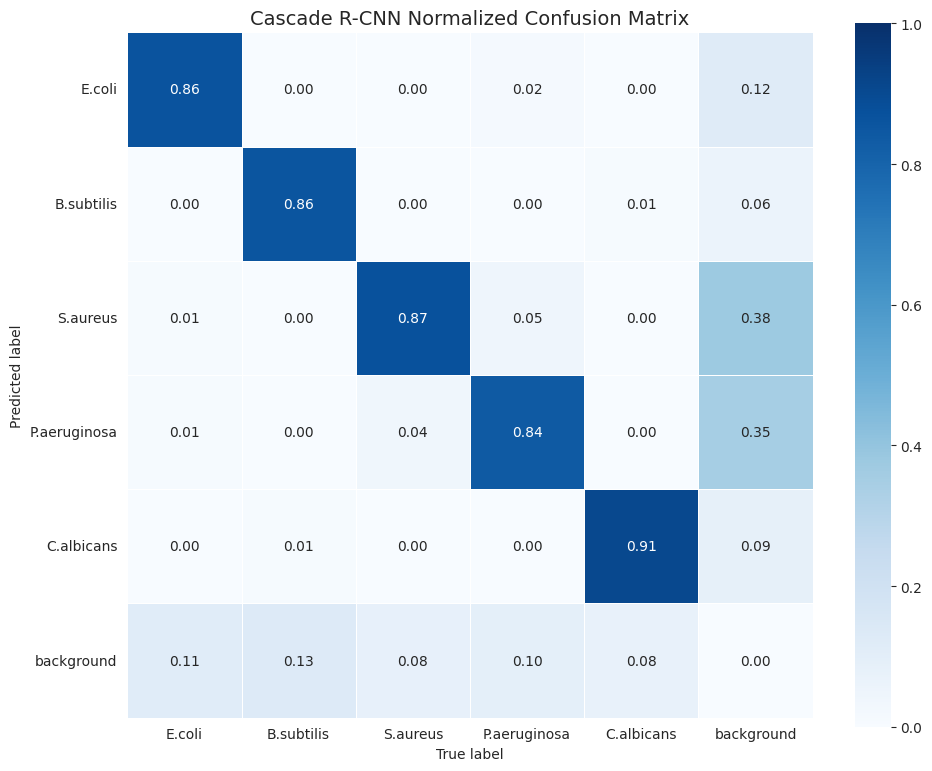

Saved normalized confusion matrix to: /home/jaden/mmdetection/work_dirs/cascade_rcnn_hparam_hrnet_lr_1e_4_bs1/confusion_matrix/normalized_confusion_matrix.png


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

WORK_DIR = Path("/home/jaden/mmdetection/work_dirs/cascade_rcnn_hparam_hrnet_lr_1e_4_bs1")
CONF_DIR = WORK_DIR / "confusion_matrix"
CONF_DIR.mkdir(parents=True, exist_ok=True)

class_names = [
    "E.coli",
    "B.subtilis",
    "S.aureus",
    "P.aeruginosa",
    "C.albicans",
    "background"
]


cm_counts = np.array([
    [5779,    0,    91,   315,     1,   948],
    [   0, 7749,     0,     3,   142,   458],
    [  73,    0, 21452,   819,    15,  2880],
    [  71,    0,   960, 14139,    24,  2673],
    [   0,   88,     9,    12, 11618,   677],
    [ 762, 1200,  2019,  1625,   984,     0]
], dtype=float)

# Normalize by true label column.
# This makes each column sum to 1.
column_sums = cm_counts.sum(axis=0, keepdims=True)

cm_normalized = np.divide(
    cm_counts,
    column_sums,
    out=np.zeros_like(cm_counts),
    where=column_sums != 0
)

plt.figure(figsize=(10, 8))

ax = sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True,
    square=True,
    linewidths=0.5,
    linecolor="white"
)

ax.set_title("Cascade R-CNN Normalized Confusion Matrix", fontsize=14)
ax.set_xlabel("True label")
ax.set_ylabel("Predicted label")

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()

save_path = CONF_DIR / "normalized_confusion_matrix.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved normalized confusion matrix to:", save_path)

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

WORK_DIR = Path("/home/jaden/mmdetection/work_dirs/cascade_rcnn_hparam_hrnet_lr_1e_4_bs1")
CONF_DIR = WORK_DIR / "confusion_matrix"
CONF_DIR.mkdir(parents=True, exist_ok=True)


tp = np.diag(cm_counts)

# Rows are predictions, so row sum = predicted as class
predicted_as_class = cm_counts.sum(axis=1)

# Columns are true labels, so column sum = support
true_class_total = cm_counts.sum(axis=0)

precision = np.divide(
    tp,
    predicted_as_class,
    out=np.zeros_like(tp),
    where=predicted_as_class != 0
)

recall = np.divide(
    tp,
    true_class_total,
    out=np.zeros_like(tp),
    where=true_class_total != 0
)

f1 = np.divide(
    2 * precision * recall,
    precision + recall,
    out=np.zeros_like(tp),
    where=(precision + recall) != 0
)

support = true_class_total.astype(int)

report_df = pd.DataFrame({
    "Class": class_names,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "Support": support
})

report_df[["Precision", "Recall", "F1-score"]] = report_df[["Precision", "Recall", "F1-score"]].round(2)

display(report_df)

,Class,Precision,Recall,F1-score,Support
0,E.coli,0.81,0.86,0.84,6685
1,B.subtilis,0.93,0.86,0.89,9037
2,S.aureus,0.85,0.87,0.86,24531
3,P.aeruginosa,0.79,0.84,0.81,16913
4,C.albicans,0.94,0.91,0.92,12784
5,background,0.00,0.00,0.00,7636


## Resume HRNet training later

Use this only when you want to continue training from epoch 3.

For resuming training, use `epoch_3.pth`, not the `best_coco_bbox_mAP_epoch_3.pth` checkpoint. The epoch checkpoint keeps the optimizer and scheduler state.

In [ ]:
# Do not run this cell unless you want to continue training.
# It still uses a subprocess because MMDetection training is safer as a separate process.

RESUME_HRNET_TRAINING = False

if RESUME_HRNET_TRAINING:
    resume_checkpoint = WORK_DIR / HRNET_RUN_NAME / "epoch_3.pth"

    if not resume_checkpoint.exists():
        raise FileNotFoundError(f"Resume checkpoint not found: {resume_checkpoint}")

    command = [
        "python",
        "tools/train.py",
        str(CONFIG_PATH),
        "--resume",
        str(resume_checkpoint),
    ]

    run_command(command, cwd=PROJECT_ROOT)
else:
    print("Resume training is off.")